In [29]:
!sudo apt update
!sudo apt install tesseract-ocr

!pip install pytesseract

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 https://cli.github.com/packages stable InRelease
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/multiverse amd64 Packages [69.2 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [3,778 kB]
Get:14 http

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm
from sklearn.decomposition import PCA
import lightgbm as lgb
from scipy.sparse import csr_matrix
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
import pytesseract
import requests
from PIL import Image
from io import BytesIO
import os
import nltk
from nltk.corpus import stopwords
import pandas as pd
from collections import Counter
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Dataset Overview

The dataset consists of **three main fields**:  

- **`catalog_content`**: Contains textual information about each product, including descriptions, specifications, and other relevant details.  
- **`price`**: Represents the selling price of the product.  
- **`url`**: Provides the link to the product image, which can be used for image-based analysis or extracting additional features (e.g., size or labels using OCR).  


In [13]:

df = pd.read_csv("/content/train.csv", engine='python', on_bad_lines='skip')


In [ ]:
df.shape

(18235, 4)

In [ ]:
pd.set_option('display.max_colwidth', None)
df["catalog_content"].head(1)

,catalog_content
0,"Item Name: La Victoria Green Taco Sauce Mild, 12 Ounce (Pack of 6)\nValue: 72.0\nUnit: Fl Oz\n"


## Data Preparation


### `catalog_content` Details

The `catalog_content` field contains the following information:  

- **`Item_name`**: Name of the product, often including the brand.  
- **`Bullet_Points`**: Key features and highlights of the product.  
- **`Value`**: Specifies the quantity or size of the item.  

For preprocessing, we extract:  
- **Brand Name** → from `Item_name`.  
- **Description** → from `Bullet_Points`.  
- **Size / Quantity** → from the `Value` field.  




In [14]:
df['Item Name'] = df['catalog_content'].apply(lambda x: x.split('Bullet Point')[0].replace('Item Name:', '').strip())
df['Description'] = df['catalog_content'].apply(lambda x: 'Bullet Point' + x.split('Bullet Point', 1)[1].strip() if 'Bullet Point' in x else '')

display(df[['catalog_content', 'Item Name', 'Description']].head())

,catalog_content,Item Name,Description
0,"Item Name: La Victoria Green Taco Sauce Mild, ...","La Victoria Green Taco Sauce Mild, 12 Ounce (P...",
1,"Item Name: Salerno Cookies, The Original Butte...","Salerno Cookies, The Original Butter Cookies, ...",Bullet Point1: Original Butter Cookies: Classi...
2,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...","Bear Creek Hearty Soup Bowl, Creamy Chicken wi...",Bullet Point1: Loaded with hearty long grain w...
3,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,Judee’s Blue Cheese Powder 11.25 oz - Gluten-F...,Bullet Point1: Add to your favorite appetizers...
4,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...","kedem Sherry Cooking Wine, 12.7 Ounce - 12 per...","Bullet Point: kedem Sherry Cooking Wine, 12.7 ..."


Initially, we attempted to extract the Brand Name by splitting the Item_Name column on the first occurrence of a comma *(',')* or hyphen *('-')*. However, this approach resulted in the new column, Split Item Name, containing unintended or mixed fields. To improve accuracy, we revised the strategy to assign the first two words of Item_Name as the Brand Name, and the remaining words as the Product Name.

In [15]:
def split_item_name(item_name):
    comma_index = item_name.find(',')
    hyphen_index = item_name.find('-')

    if comma_index != -1 and (hyphen_index == -1 or comma_index < hyphen_index):
        return item_name.split(',', 1)[0].strip()
    elif hyphen_index != -1 and (comma_index == -1 or hyphen_index < comma_index):
        return item_name.split('-', 1)[0].strip()
    else:
        return item_name.strip()

df['Split Item Name'] = df['Item Name'].apply(split_item_name)

display(df[['Item Name', 'Split Item Name']].head())

,Item Name,Split Item Name
0,"La Victoria Green Taco Sauce Mild, 12 Ounce (P...",La Victoria Green Taco Sauce Mild
1,"Salerno Cookies, The Original Butter Cookies, ...",Salerno Cookies
2,"Bear Creek Hearty Soup Bowl, Creamy Chicken wi...",Bear Creek Hearty Soup Bowl
3,Judee’s Blue Cheese Powder 11.25 oz - Gluten-F...,Judee’s Blue Cheese Powder 11.25 oz
4,"kedem Sherry Cooking Wine, 12.7 Ounce - 12 per...",kedem Sherry Cooking Wine


In [16]:
def extract_brand_and_product(item_name):
    words = item_name.split()
    brand_name = ' '.join(words[:2]) if len(words) >= 2 else item_name
    remaining_text = ' '.join(words[2:]) if len(words) > 2 else ''

    comma_index = remaining_text.find(',')
    hyphen_index = remaining_text.find('-')

    if comma_index != -1 and (hyphen_index == -1 or comma_index < hyphen_index):
        product_name = remaining_text[:comma_index].strip()
    elif hyphen_index != -1 and (comma_index == -1 or hyphen_index < comma_index):
        product_name = remaining_text[:hyphen_index].strip()
    else:
        product_name = remaining_text.strip()

    return brand_name, product_name

df[['Brand Name', 'Product Name']] = df['Item Name'].apply(lambda x: pd.Series(extract_brand_and_product(x)))

display(df[['Item Name', 'Brand Name', 'Product Name']].head())

,Item Name,Brand Name,Product Name
0,"La Victoria Green Taco Sauce Mild, 12 Ounce (P...",La Victoria,Green Taco Sauce Mild
1,"Salerno Cookies, The Original Butter Cookies, ...","Salerno Cookies,",The Original Butter Cookies
2,"Bear Creek Hearty Soup Bowl, Creamy Chicken wi...",Bear Creek,Hearty Soup Bowl
3,Judee’s Blue Cheese Powder 11.25 oz - Gluten-F...,Judee’s Blue,Cheese Powder 11.25 oz
4,"kedem Sherry Cooking Wine, 12.7 Ounce - 12 per...",kedem Sherry,Cooking Wine


In [17]:
df=df.drop(columns=['Item Name','Split Item Name'])

In [18]:


def extract_size_from_description(description):
    size_match = re.search(r'Value: (\d+\.?\d*)\nUnit:', description) or re.search(r'Value: (\d+\.?\d*)\nOz:', description)
    if size_match:
        return float(size_match.group(1))
    return None

df['Size'] = df['catalog_content'].apply(extract_size_from_description)

display(df[['Description', 'Size']].head())

,Description,Size
0,,72.00
1,Bullet Point1: Original Butter Cookies: Classi...,32.00
2,Bullet Point1: Loaded with hearty long grain w...,11.40
3,Bullet Point1: Add to your favorite appetizers...,11.25
4,"Bullet Point: kedem Sherry Cooking Wine, 12.7 ...",12.00


In [ ]:
df.head()

,sample_id,catalog_content,image_link,price,Description,Brand Name,Product Name,Size
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,,La Victoria,Green Taco Sauce Mild,72.00
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,Bullet Point1: Original Butter Cookies: Classi...,"Salerno Cookies,",The Original Butter Cookies,32.00
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,Bullet Point1: Loaded with hearty long grain w...,Bear Creek,Hearty Soup Bowl,11.40
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,Bullet Point1: Add to your favorite appetizers...,Judee’s Blue,Cheese Powder 11.25 oz,11.25
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,"Bullet Point: kedem Sherry Cooking Wine, 12.7 ...",kedem Sherry,Cooking Wine,12.00


In [20]:


all_product_names = ' '.join(df['Product Name'].dropna().tolist())


words = re.findall(r'\b[a-zA-Z]+\b', all_product_names.lower())

word_counts = Counter(words)

most_common_words = word_counts.most_common(20)

print("Most common words in Product Names:")
for word, count in most_common_words:
    print(f"{word}: {count}")

Most common words in Product Names:
tea: 1976
oz: 1838
pack: 1302
of: 1087
organic: 982
mix: 967
value: 918
unit: 905
coffee: 894
chocolate: 797
with: 720
candy: 679
and: 645
free: 643
sauce: 611
ounce: 593
sugar: 495
bags: 495
count: 488
for: 460


To facilitate analysis and modeling, we categorized prices into three quantiles—Low, Medium, and High—using **pd.qcut**. This assigns each product to a price category based on its relative value within the dataset.

In [21]:

price_distribution = df['price'].describe()
print(price_distribution)

df['price_category'] = pd.qcut(df['price'], q=3, labels=['Low', 'Medium', 'High'])

display(df[['price', 'price_category']].head())

count    18235.000000
mean        23.421090
std         30.558519
min          0.130000
25%          6.787500
50%         14.000000
75%         28.362500
max        613.580000
Name: price, dtype: float64


,price,price_category
0,4.89,Low
1,13.12,Medium
2,1.97,Low
3,30.34,High
4,66.49,High


## Data analysis

### Analyzing Common Words by Price Category

To understand how product descriptions vary with price, we analyzed the most frequent words in the `catalog_content` column for each price segment—**Low**, **Medium**, and **High**.  

This approach helps identify patterns or keywords associated with different price tiers. For example, low-priced items might frequently include words like “basic”, “small”, or “pack”, whereas high-priced items might contain terms like “premium”, “organic”, or “exclusive”.

We performed the following steps:
1. Filtered products by `price_category`.
2. Tokenized the `catalog_content` for each category.
3. Counted word frequencies to identify the most common words per price segment.

This analysis provides insights into **textual features that correlate with product pricing**, which can be useful for feature engineering in predictive models.


In [22]:
catalog_content_by_category = {}

for category in ['Low', 'Medium', 'High']:
    category_df = df[df['price_category'] == category]
    catalog_content_by_category[category] = ' '.join(category_df['catalog_content'].dropna().tolist())

for category, text in catalog_content_by_category.items():
    print(f"Length of catalog_content for {category} price category: {len(text)}")

Length of catalog_content for Low price category: 3726717
Length of catalog_content for Medium price category: 5896894
Length of catalog_content for High price category: 6924587


In [23]:


try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
    print("NLTK stopwords downloaded.")

stop_words = set(stopwords.words('english'))

common_words_by_category = {}

for category, text in catalog_content_by_category.items():
    text_lower = text.lower()

    words = re.findall(r'\b[a-zA-Z]+\b', text_lower)

    filtered_words = [word for word in words if word not in stop_words]

    word_counts = Counter(filtered_words)

    common_words_by_category[category] = word_counts.most_common(50)

for category, common_words in common_words_by_category.items():
    print(f"\nMost common words in catalog_content for {category} price category:")
    for word, count in common_words:
        print(f"{word}: {count}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


NLTK stopwords downloaded.

Most common words in catalog_content for Low price category:
point: 19830
bullet: 19816
item: 6416
value: 6317
name: 6211
unit: 6198
ounce: 5922
oz: 5286
free: 4034
pack: 3347
flavor: 2981
product: 2520
made: 2286
tea: 2228
organic: 2130
gluten: 2052
delicious: 1820
description: 1795
taste: 1784
perfect: 1744
sugar: 1716
ingredients: 1675
fl: 1644
flavors: 1593
count: 1527
chocolate: 1480
snack: 1450
mix: 1420
natural: 1401
candy: 1389
non: 1368
sweet: 1318
water: 1314
great: 1277
quality: 1227
sauce: 1215
gmo: 1176
contains: 1158
enjoy: 1124
fruit: 1119
food: 1087
kosher: 1059
bag: 1050
artificial: 1044
per: 1044
one: 1039
easy: 1030
certified: 981
whole: 962
snacks: 940

Most common words in catalog_content for Medium price category:
point: 22525
bullet: 22497
value: 6352
item: 6250
name: 6181
unit: 6094
free: 5620
flavor: 5149
ounce: 5127
coffee: 4983
tea: 4759
oz: 4051
product: 3951
taste: 3282
pack: 3210
perfect: 3142
sugar: 2952
organic: 2909
made: 287

/tmp/ipython-input-4078721377.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette='viridis')


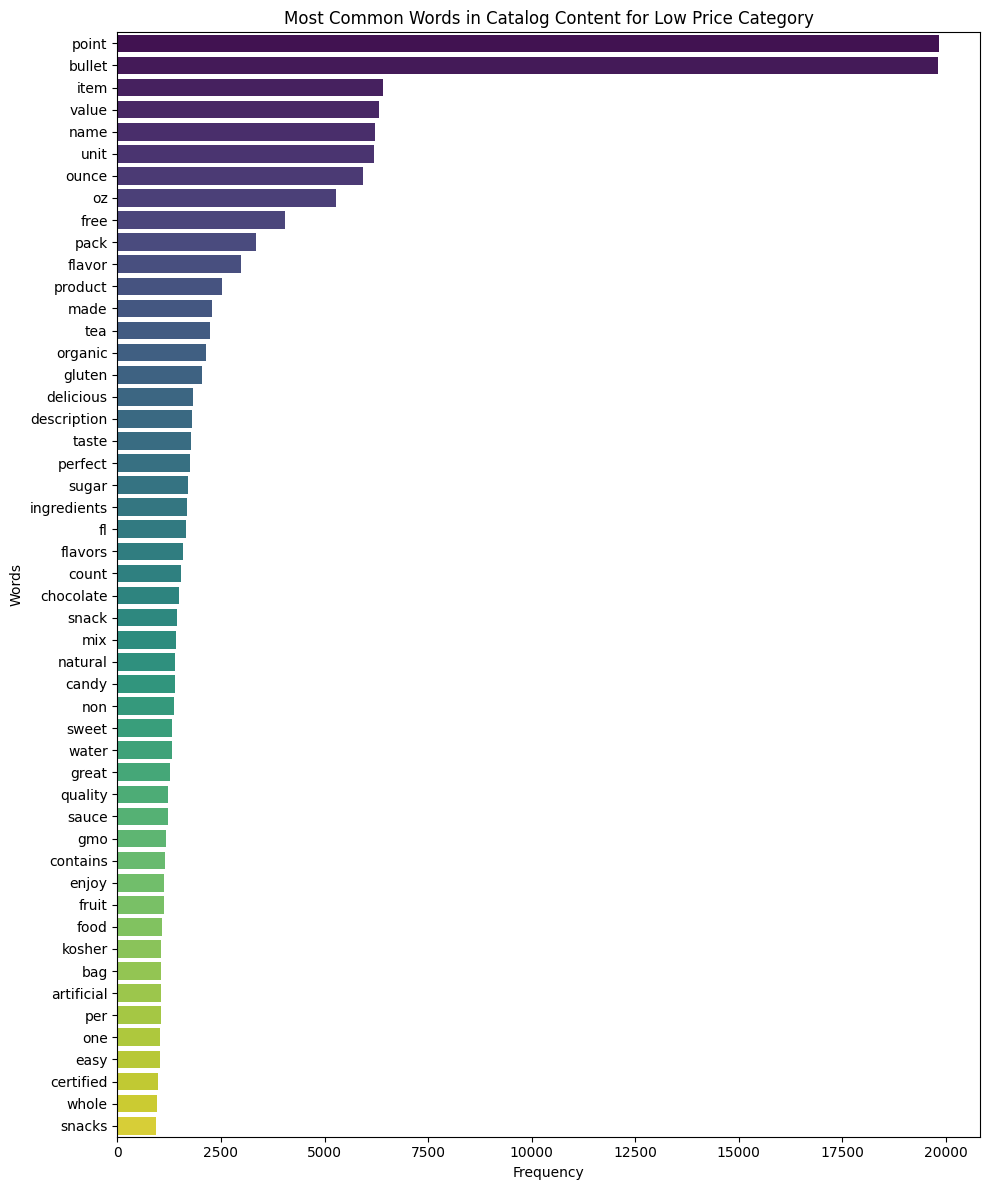

/tmp/ipython-input-4078721377.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette='viridis')


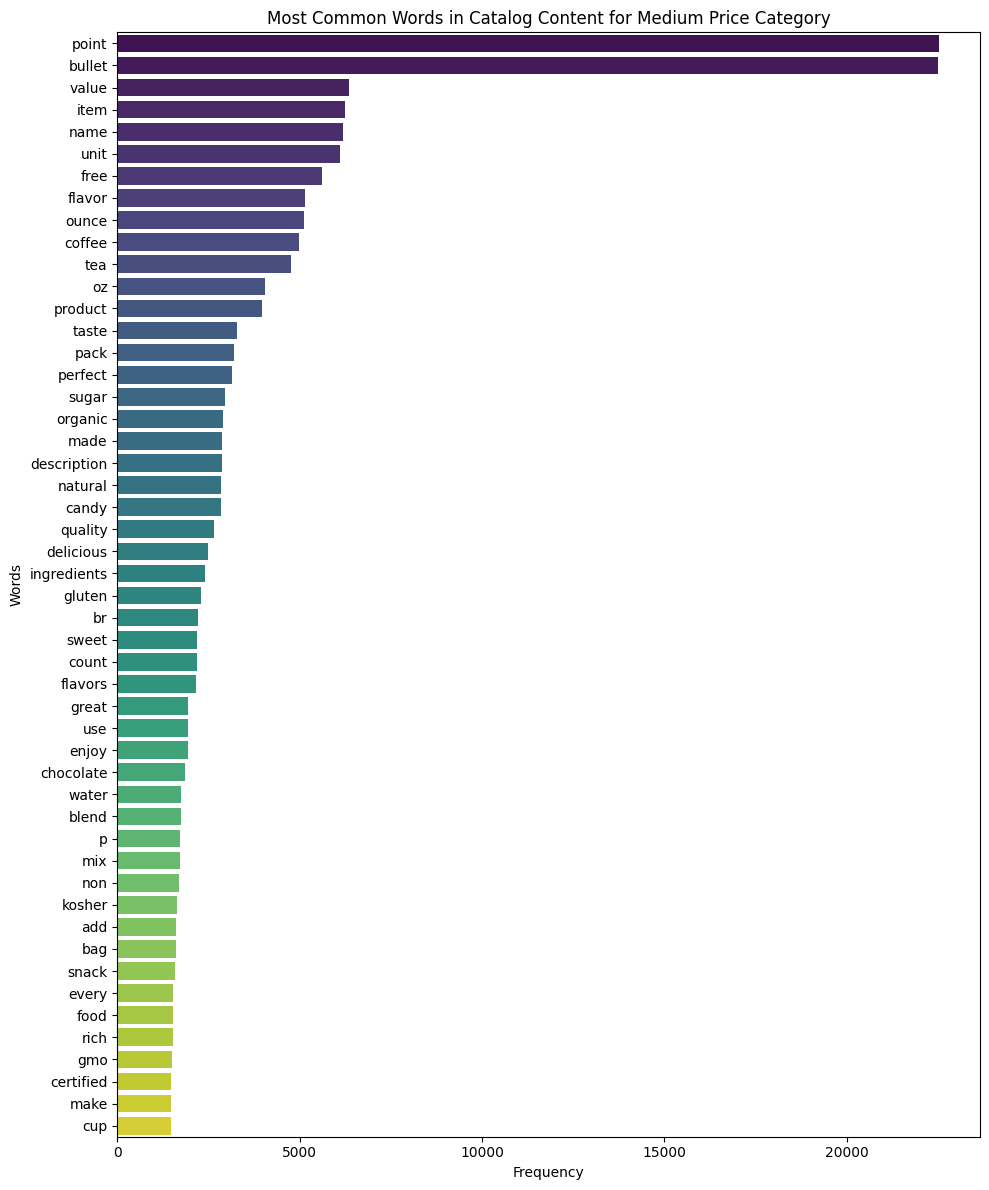

/tmp/ipython-input-4078721377.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette='viridis')


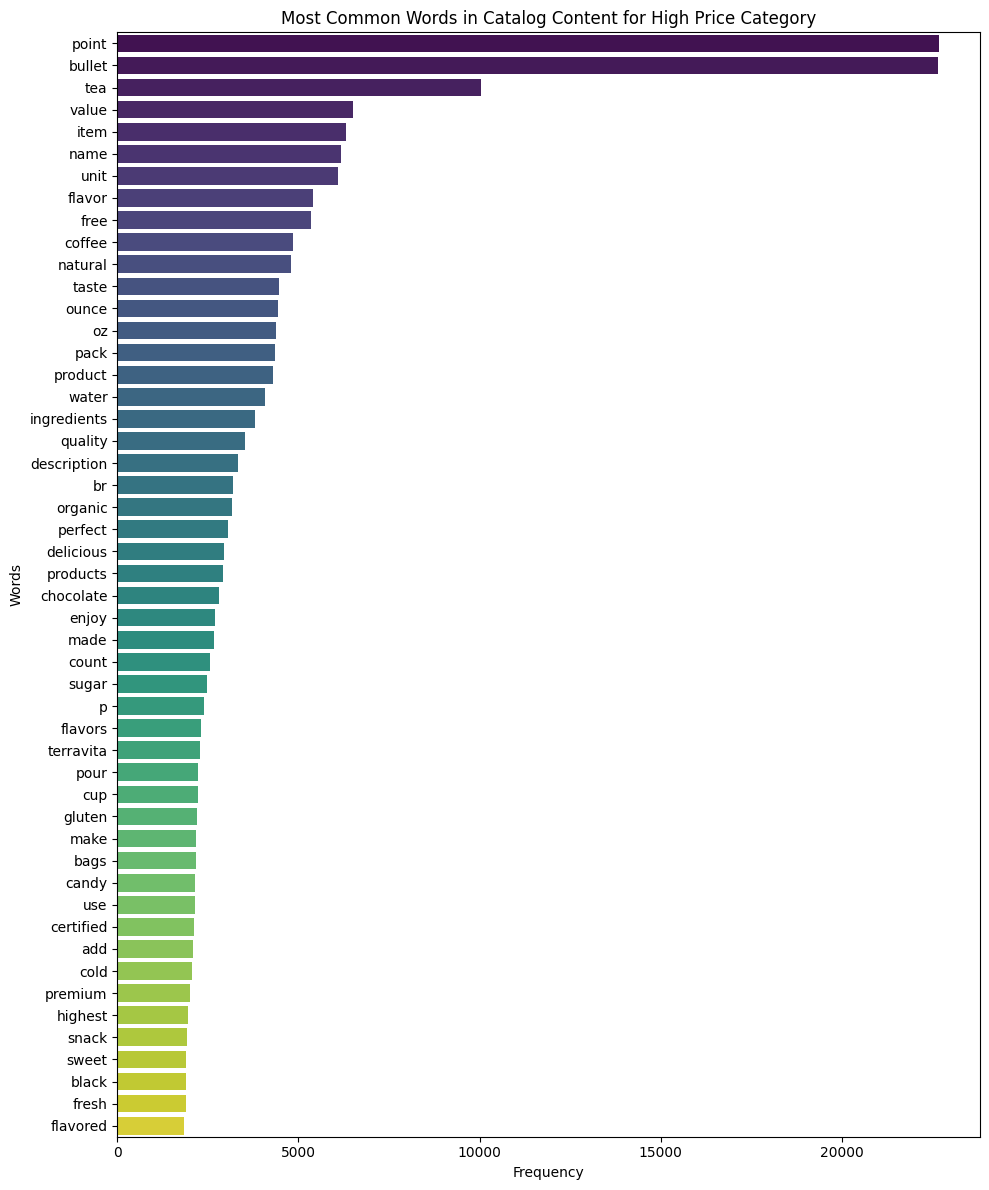

In [31]:


for category, common_words in common_words_by_category.items():
    words = [word for word, count in common_words]
    counts = [count for word, count in common_words]

    plt.figure(figsize=(10, 12))
    sns.barplot(x=counts, y=words, palette='viridis')


    plt.title(f'Most Common Words in Catalog Content for {category} Price Category')
    plt.xlabel('Frequency')
    plt.ylabel('Words')

    plt.tight_layout()
    plt.show()

### Most Common Words by Price Category

We analyzed the `catalog_content` of products to identify the most frequent words in each price segment.

- **Low Price Items:**  
  - Most common words: `artificial`,`pack` , `free` etc

- **Medium & High Price Items:**  
  - Most common words: `organic`, `rich`, `premium`

This analysis highlights textual patterns that differentiate products by price tier.  
For example, low priced items often include descriptors like “artificial”, while higher priced items emphasize quality or exclusivity with words like “organic”, “rich”, and “premium”.


In [24]:
df['premium'] = df['catalog_content'].str.contains('premium|rich|flavored', case=False, na=False)

df['artificial'] = df['catalog_content'].str.contains('artificial', case=False, na=False)
df['certified']=df['catalog_content'].str.contains('certified',case=False,na=False)
display(df[['catalog_content', 'premium', 'artificial']].head())

,catalog_content,premium,artificial
0,"Item Name: La Victoria Green Taco Sauce Mild, ...",False,False
1,"Item Name: Salerno Cookies, The Original Butte...",False,False
2,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",False,False
3,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,False,False
4,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",False,False


### Extracting Missing Size Information from Images

During data preprocessing, we identified rows where the `Size` field was missing. To recover this information, we leveraged the associated product images and applied **OCR (Optical Character Recognition)** techniques to extract the size details directly from the images.




In [25]:
null_size_rows = df[df['Size'].isnull()]

display(null_size_rows.head())

print(f"\nNumber of rows with null size: {len(null_size_rows)}")

,sample_id,catalog_content,image_link,price,Description,Brand Name,Product Name,Size,price_category,premium,artificial,certified
48,186165,Item Name: Seasons Brand Imported Skinless & B...,https://m.media-amazon.com/images/I/41HJmvLaTy...,2.540,,Seasons Brand,Imported Skinless & Boneless Sardines in Water...,NaN,Low,False,False,False
82,218503,Item Name: Wellsley Farms Coarse Kosher Salt. ...,https://m.media-amazon.com/images/I/81DBENbjUQ...,7.465,Bullet Point1: Origin: Wellsley Farms Kosher S...,Wellsley Farms,Coarse Kosher Salt. 3 Pounds. Passover Approve...,NaN,Low,True,False,False
255,238772,Item Name: DYE INK PAD Stamperia Coffee\nBulle...,https://m.media-amazon.com/images/I/81EPOspMgs...,9.490,Bullet Point1: Nice ink pad for DIY\nBullet Po...,DYE INK,PAD Stamperia Coffee,NaN,Medium,False,False,False
299,231191,Item Name: Starbucks By Nespresso Single Origi...,https://m.media-amazon.com/images/I/41JwYLWvsr...,12.170,Bullet Point1: Capsules Are Developed With And...,Starbucks By,Nespresso Single Origin Columbia Coffee Pods,NaN,Medium,False,False,False
372,96295,Item Name: Cavender's All Purpose Greek Season...,https://m.media-amazon.com/images/I/313s23mjHU...,21.775,Bullet Point1: Instantly add scrumptious flavo...,Cavender's All,Purpose Greek Seasoning (Salt Free/No MSG),NaN,Medium,False,False,False



Number of rows with null size: 235


In [26]:


image_dir = 'null_size_images'

if not os.path.exists(image_dir):
    os.makedirs(image_dir)
    print(f"Created directory: {image_dir}")

image_info_to_download = df[df['Size'].isnull()][['sample_id', 'image_link']]

print(f"Starting image download to '{image_dir}'...")

download_count = 0
failed_downloads = []

for index, row in image_info_to_download.iterrows():
    sample_id = row['sample_id']
    image_url = row['image_link']
    file_name = os.path.join(image_dir, f'{sample_id}.jpg')

    try:
        response = requests.get(image_url, stream=True)
        response.raise_for_status()

        img = Image.open(BytesIO(response.content))

        img.save(file_name)

        download_count += 1
        if download_count % 50 == 0:
            print(f"Downloaded {download_count} images...")

    except requests.exceptions.RequestException as e:
        failed_downloads.append({'sample_id': sample_id, 'url': image_url, 'error': str(e)})
        print(f"Failed to download image for sample_id {sample_id} from {image_url}: {e}")
    except Exception as e:
        failed_downloads.append({'sample_id': sample_id, 'url': image_url, 'error': str(e)})
        print(f"An error occurred processing image for sample_id {sample_id} from {image_url}: {e}")


print("\nDownload process finished.")
print(f"Successfully downloaded {download_count} images.")
if failed_downloads:
    print(f"Failed to download {len(failed_downloads)} images. Details:")
    for failure in failed_downloads:
        print(f"  Sample ID: {failure['sample_id']}, URL: {failure['url']}, Error: {failure['error']}")

Created directory: null_size_images
Starting image download to 'null_size_images'...
Downloaded 50 images...
Downloaded 100 images...
Downloaded 150 images...
Downloaded 200 images...

Download process finished.
Successfully downloaded 235 images.


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18235 entries, 0 to 18234
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   sample_id        18235 non-null  int64   
 1   catalog_content  18235 non-null  object  
 2   image_link       18235 non-null  object  
 3   price            18235 non-null  float64 
 4   Description      18235 non-null  object  
 5   Brand Name       18235 non-null  object  
 6   Product Name     18235 non-null  object  
 7   Size             18000 non-null  float64 
 8   price_category   18235 non-null  category
 9   premium          18235 non-null  bool    
 10  artificial       18235 non-null  bool    
 11  certified        18235 non-null  bool    
dtypes: bool(3), category(1), float64(2), int64(1), object(5)
memory usage: 1.2+ MB


In [28]:


image_dir = 'null_size_images'

image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]

print(f"Found {len(image_files)} images in the directory.")

if image_files:
    first_image_path = os.path.join(image_dir, image_files[0])
    try:
        img = Image.open(first_image_path)
        print(f"\nSuccessfully loaded the first image: {image_files[0]}")
        print(f"Image format: {img.format}, Size: {img.size}, Mode: {img.mode}")
        img.close()
    except Exception as e:
        print(f"Could not load the first image {image_files[0]}: {e}")
else:
    print("No image files found in the directory.")



Found 235 images in the directory.

Successfully loaded the first image: 90163.jpg
Image format: JPEG, Size: (164, 164), Mode: RGB


In [30]:



image_dir = 'null_size_images'

image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
extracted_text_results = []

print(f"Starting text extraction from {len(image_files)} images...")

for image_file in image_files:
    image_path = os.path.join(image_dir, image_file)
    sample_id = int(os.path.splitext(image_file)[0])

    try:
        img = Image.open(image_path)

        text = pytesseract.image_to_string(img)

        extracted_text_results.append({'sample_id': sample_id, 'extracted_text': text.strip()})

        if len(extracted_text_results) % 100 == 0:
            print(f"Processed {len(extracted_text_results)} images...")

    except Exception as e:
        print(f"Error processing image {image_file}: {e}")
        extracted_text_results.append({'sample_id': sample_id, 'extracted_text': f"Error: {e}"})


print("\nText extraction complete.")

extracted_text_df = pd.DataFrame(extracted_text_results)

print("\nExtracted text for the first few images:")
display(extracted_text_df.head())

Starting text extraction from 235 images...
Processed 100 images...
Processed 200 images...

Text extraction complete.

Extracted text for the first few images:


,sample_id,extracted_text
0,90163,eBuNtet Bre
1,235869,
2,226033,BUD Maa\n\nese. W 200»\n\nFRESH ROASTED\nCOFFE...
3,238179,
4,152621,ECO ia\nGREEN\nans.


In [32]:
def extract_size_from_text(text):
    size_patterns = [
        r'(\d+\.?\d*)\s*(?:ounces?|oz|fl oz)',
        r'(\d+\.?\d*)\s*(?:milliliters?|ml)',
        r'(\d+\.?\d*)\s*(?:liters?|l)',
        r'(\d+\.?\d*)\s*(?:pounds?|lbs?)',
        r'(\d+\.?\d*)\s*(?:kilograms?|kg)',
        r'(\d+)\s*(?:count|ct)',
    ]

    for pattern in size_patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            return float(match.group(1))
    return None

text_lookup = extracted_text_df.set_index('sample_id')['extracted_text'].to_dict()

for index, row in df.iterrows():
    if pd.isnull(row['Size']):
        sample_id = row['sample_id']
        extracted_text = text_lookup.get(sample_id, "")
        if extracted_text:
            extracted_size = extract_size_from_text(extracted_text)
            if extracted_size is not None:
                df.at[index, 'Size'] = extracted_size

print("Updated 'Size' column based on extracted text from images.")

updated_rows = df[df['Size'].notnull() & df['sample_id'].isin(extracted_text_df['sample_id'].tolist())]
display(updated_rows[['sample_id', 'Size', 'catalog_content']].head())

Updated 'Size' column based on extracted text from images.


,sample_id,Size,catalog_content
82,218503,2.00,Item Name: Wellsley Farms Coarse Kosher Salt. ...
653,284687,24.00,Item Name: SAUCE TOMATO BASIL 24OZ\nValue: nan...
1271,155498,1.00,Item Name: Finest Call Passion Fruit Puree 1l\...
1923,216288,0.40,Item Name: Juan Valdez Classic Medium Roast Co...
2530,90173,1.25,"Item Name: Wye River Crab Cake Seasoning Mix, ..."


In [ ]:
df.head()

,sample_id,catalog_content,image_link,price,Description,Brand Name,Product Name,Size,price_category,premium,artificial,certified
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,,La Victoria,Green Taco Sauce Mild,72.00,Low,False,False,False
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,Bullet Point1: Original Butter Cookies: Classi...,"Salerno Cookies,",The Original Butter Cookies,32.00,Medium,False,False,False
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,Bullet Point1: Loaded with hearty long grain w...,Bear Creek,Hearty Soup Bowl,11.40,Low,False,False,False
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,Bullet Point1: Add to your favorite appetizers...,Judee’s Blue,Cheese Powder 11.25 oz,11.25,High,False,False,False
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,"Bullet Point: kedem Sherry Cooking Wine, 12.7 ...",kedem Sherry,Cooking Wine,12.00,High,False,False,False


In [34]:
df['premium'] = df['premium'].apply(lambda x: 1 if x else 0)
df['artificial'] = df['artificial'].apply(lambda x: 1 if x else 0)
df['certified'] = df['certified'].apply(lambda x: 1 if x else 0)

In [ ]:
df.head()

,sample_id,catalog_content,image_link,price,Description,Brand Name,Product Name,Size,price_category,premium,artificial,certified
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,,La Victoria,Green Taco Sauce Mild,72.00,Low,0,0,0
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,Bullet Point1: Original Butter Cookies: Classi...,"Salerno Cookies,",The Original Butter Cookies,32.00,Medium,0,0,0
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,Bullet Point1: Loaded with hearty long grain w...,Bear Creek,Hearty Soup Bowl,11.40,Low,0,0,0
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,Bullet Point1: Add to your favorite appetizers...,Judee’s Blue,Cheese Powder 11.25 oz,11.25,High,0,0,0
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,"Bullet Point: kedem Sherry Cooking Wine, 12.7 ...",kedem Sherry,Cooking Wine,12.00,High,0,0,0


## Model Training

Our modeling approach involved multiple steps to evaluate the impact of different text representations on price prediction:

1. **TF-IDF on Combined Text:**  
   - We first combined the textual columns (`Description`, `Product Name`, `Brand Name`) into a single field.  
   - TF-IDF vectors were generated from this combined text and used as input features along with numeric features.  
   - A **Random Forest Regressor** was trained on these features to predict product prices.

2. **TF-IDF on Separate Columns:**  
   - To improve model efficiency, we generated TF-IDF vectors for each textual column separately instead of combining them.  
   - The separate embeddings were then concatenated with numeric features and used to train another LightGBM model.  
   - This approach allowed the model to capture column-specific textual information more effectively.

3. **BERT Embeddings:**  
   - Finally, we extracted **contextual embeddings** from BERT for the text columns.  
   - These embeddings were combined with numeric features and used to train a LightGBM model.  
   - This step leveraged the semantic understanding of BERT to further enhance the predictive performance of the model.


### TF-IDF on Combined Text:

In [ ]:

df['combined_text'] = df['Description'].fillna('') + ' ' + \
                      df['Product Name'].fillna('') + ' ' + \
                      df['Brand Name'].fillna('')


tfidf_vectorizer = TfidfVectorizer(stop_words='english', min_df=5)
tfidf_features = tfidf_vectorizer.fit_transform(df['combined_text'])


In [ ]:



numeric_cols = ['Size', 'premium', 'artificial', 'certified']
numeric_features = df[numeric_cols].fillna(0)

scaler = StandardScaler()
numeric_features_scaled = scaler.fit_transform(numeric_features)

ohe = OneHotEncoder()
category_features = ohe.fit_transform(df[['price_category']])


In [ ]:


X = hstack([tfidf_features, numeric_features_scaled, category_features])
y = df['price']


In [ ]:


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:


model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:



mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)


RMSE: 22.558521442961403


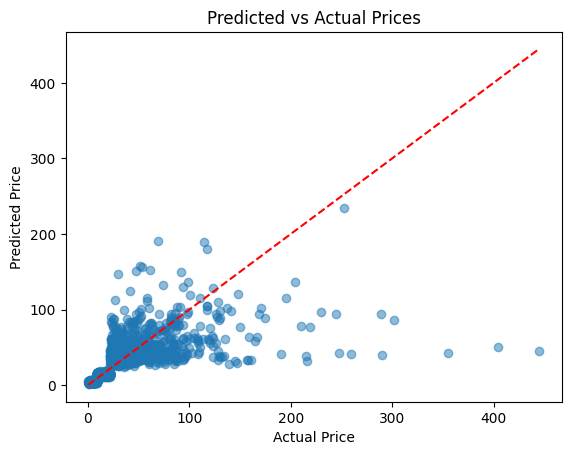

In [ ]:

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


### TF-IDF on Separate Columns

In [40]:


tfidf_desc = TfidfVectorizer(stop_words='english', min_df=5)
desc_features = tfidf_desc.fit_transform(df['Description'].fillna(''))

tfidf_product = TfidfVectorizer(stop_words='english', min_df=5)
product_features = tfidf_product.fit_transform(df['Product Name'].fillna(''))

tfidf_brand = TfidfVectorizer(stop_words='english', min_df=5)
brand_features = tfidf_brand.fit_transform(df['Brand Name'].fillna(''))


In [59]:



X_text = hstack([desc_features, product_features, brand_features])

numeric_cols = ['Size', 'premium', 'artificial', 'certified']
numeric_features = df[numeric_cols].copy()

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
numeric_features.loc[:, 'Size'] = imputer.fit_transform(numeric_features[['Size']])


X_num = csr_matrix(numeric_features.values)
X = hstack([X_text, X_num])
y = df['price'].values

In [60]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [62]:




train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)


params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.1,
    'num_leaves': 31,
    'verbose': -1
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=20)]
)


y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[83]	valid_0's rmse: 22.4197
RMSE: 22.41972179426671


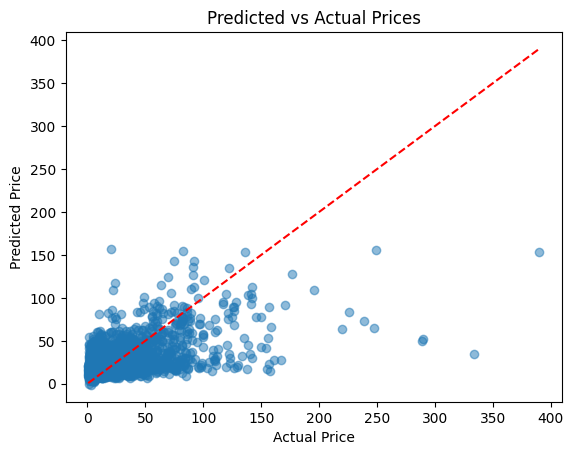

In [63]:

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

### BERT Embeddings

In [37]:


model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
text_model = AutoModel.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
text_model.to(device)
text_model.eval()

def get_text_embeddings(texts, max_len=128, batch_size=32):
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i+batch_size]

        enc = tokenizer(batch_texts, padding=True, truncation=True,
                        max_length=max_len, return_tensors="pt").to(device)

        with torch.no_grad():
            out = text_model(**enc)
            batch_emb = out.last_hidden_state.mean(dim=1).cpu().numpy()

        all_embeddings.append(batch_emb)

    return np.vstack(all_embeddings)

df['combined_text'] = (
    df['Brand Name'].fillna('') + ' ' +
    df['Product Name'].fillna('') + ' ' +
    df['Description'].fillna('')
)

texts = df['combined_text'].tolist()
embeddings = get_text_embeddings(texts, max_len=128, batch_size=32)

X_text = embeddings
X_num = df[['Size', 'premium', 'artificial', 'certified']].values
X = np.hstack([X_text, X_num])
y = df['price'].values


100%|██████████| 570/570 [1:06:10<00:00,  6.97s/it]


In [51]:
X_text = embeddings
X_num = df[['Size', 'premium', 'artificial', 'certified']].values
X = np.hstack([X_text, X_num])
y = df['price'].values

In [38]:
df.to_csv("final.csv")

In [56]:


pca = PCA(n_components=100, random_state=42)
X_text_reduced = pca.fit_transform(X_text)


X_final = np.hstack([X_text_reduced, X_num])


X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)


train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1
}


model = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=20)]
)


y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[211]	valid_0's rmse: 23.3087
RMSE: 23.30866133741412


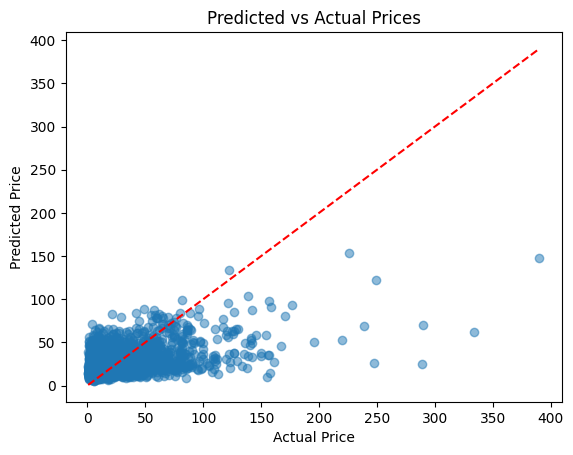

In [58]:

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()
